Connect to Drive

In [22]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import statistics
import pandas as pd
import numpy as np

In [24]:
data = pd.read_csv('/content/drive/MyDrive/Data_eda/raw_sales.csv')

In [25]:
data.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [26]:
# Function to Detection Outlier on one-dimentional datasets.

def find_anomalies(data):
  #define a list to accumlate anomalies
  anomalies = []

  # Set upper and lower limit to 3 standard deviation
  random_data_mean = statistics.mean(data)
  random_data_std = statistics.stdev(data)

  # 3-standard deviation
  anomaly_cutoff = random_data_std*3

  lower_limit = random_data_mean - anomaly_cutoff
  upper_limit = random_data_mean + anomaly_cutoff

  # Filtering outliers
  for outlier in data:
    if (outlier < lower_limit) or (outlier > upper_limit):
      anomalies.append(outlier)

  return anomalies

In [27]:
data.columns

Index(['datesold', 'postcode', 'price', 'propertyType', 'bedrooms'], dtype='object')

In [28]:
lst1 = find_anomalies(data['price'])
print(len(lst1))

461


In [29]:
print(data['price'].shape)
print(type(data['price']))

(29580,)
<class 'pandas.core.series.Series'>


Skewness of the Data

In [30]:
data['price'].skew()

np.float64(4.312009366902366)

In [31]:
import seaborn as sns

<Axes: xlabel='price', ylabel='Density'>

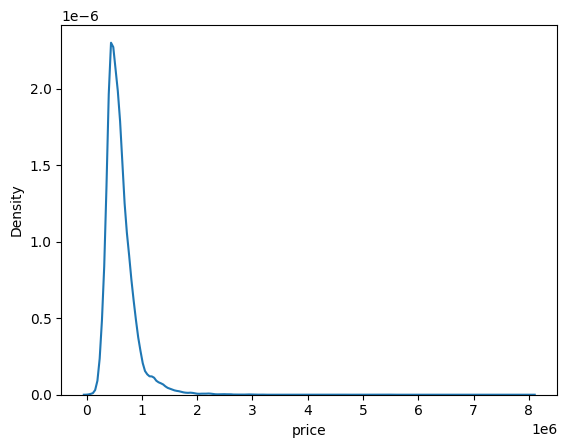

In [32]:
sns.kdeplot(data['price'])

In [33]:
# transformed price
data['price_trans'] = np.log(data['price'])

In [34]:
data['price_trans']

,price_trans
0,13.171154
1,12.577636
2,12.700769
3,12.847927
4,12.644328
...,...
29575,13.122363
29576,13.235692
29577,13.049685
29578,13.286181


In [35]:
data['price_trans'].skew()

np.float64(0.4731646269984763)

In [36]:
lst2 = find_anomalies(data['price_trans'])

In [37]:
print(lst2)
print(len(lst2))

[14.392123922268269, 11.816726919301892, 15.068273526459642, 14.557447902693651, 11.512925464970229, 14.77102200299171, 14.444119217386648, 14.603967918328545, 14.669925886120343, 15.80338490611862, 14.392123922268269, 14.690979295318174, 11.608235644774552, 14.538216540765763, 14.375126345899696, 14.508657738524219, 15.238618892206881, 14.392123922268269, 14.73180128983843, 15.506528457390797, 14.603967918328545, 14.68050799545088, 14.557447902693651, 14.48333993053993, 14.498607402670718, 14.457364444136669, 14.830741237693333, 11.813030057420567, 14.446782334806132, 11.982929094215963, 11.33857207782545, 11.141861783579396, 12.072541252905651, 14.462613800022813, 14.491002803285499, 12.058152515453552, 14.390718440659533, 11.350406535472453, 14.77102200299171, 14.457364444136669, 14.966082585563095, 14.496078956317358, 14.457364444136669, 14.394928973195876, 14.547878451677501, 15.03928598958639, 14.53335035111459, 14.75160391713461, 14.457364444136669, 14.403852624158093, 14.483339

In [38]:
len(data)

29580

<Axes: xlabel='price_trans', ylabel='Density'>

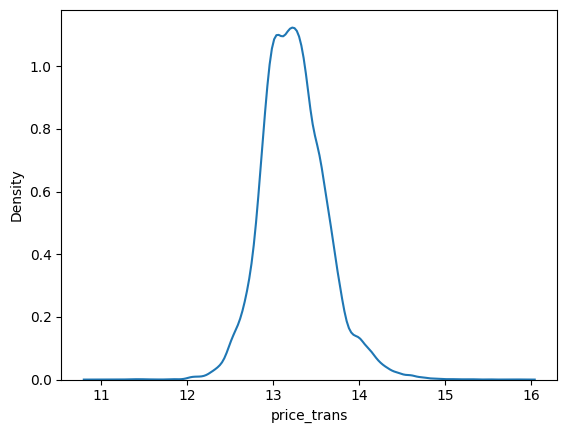

In [39]:
sns.kdeplot(data['price_trans'])

In [42]:
# double log transformation
data['price_trans_double'] = np.log(data['price_trans'])

In [43]:
lst3 = find_anomalies(data['price_trans_double'])

In [44]:
print(lst3)
print(len(lst3))

[2.469516063250643, 2.7125914424696296, 2.6781027459965556, 2.443470357682056, 2.6926672886648078, 2.6702873571464947, 2.681293267018076, 2.685799540071259, 2.7602241516524435, 2.687233652042676, 2.4517148155804023, 2.6767808057627542, 2.6747455566574194, 2.7238329222809696, 2.6900085101561477, 2.741261126048661, 2.681293267018076, 2.6865206271823907, 2.6781027459965556, 2.67299901854652, 2.6740526036191548, 2.6712039348441956, 2.6967021372131965, 2.469203164398985, 2.6704717139705427, 2.483483061484839, 2.428210371308124, 2.4107093465297047, 2.490933555856897, 2.671566961116171, 2.673527960513875, 2.489740988473999, 2.4292535613892587, 2.6926672886648078, 2.6712039348441956, 2.7057864798550955, 2.673878196051612, 2.6712039348441956, 2.67744517210479, 2.7106658432981137, 2.676446032634445, 2.6913518170187674, 2.6712039348441956, 2.67299901854652, 2.7106658432981137, 2.671747712973357, 2.670102473917304, 2.687233652042676, 2.677774799675404, 2.6712039348441956, 2.678915364384639, 2.6730

In [45]:
data['price_trans_double'].skew()

np.float64(0.33092530655758573)

<Axes: xlabel='price_trans_double', ylabel='Density'>

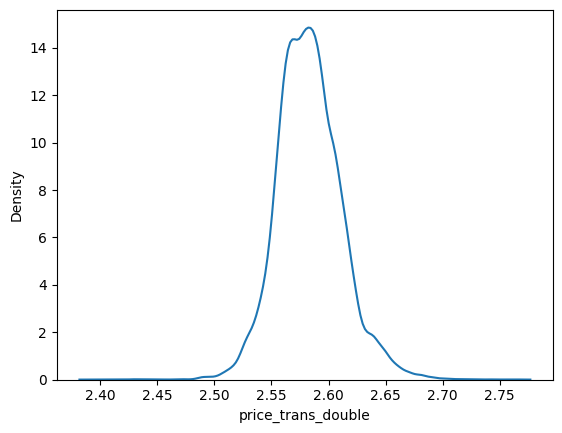

In [46]:
sns.kdeplot(data['price_trans_double'])

* Anything below 40, or above 80 are considered as outliers

### **Box-Plots**

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

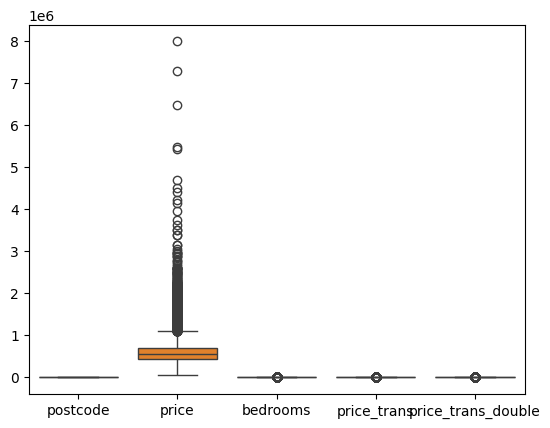

In [48]:
sns.boxplot(data=data)

The above code displays the plot below

* As you can see, it considers everything above 75 or below ~ -35 to be an outlier. The results are very close to method 1 above

In [49]:
import pandas as pd

In [50]:
df = pd.DataFrame(data)

In [51]:
len(df)

29580

In [52]:
df

,datesold,postcode,price,propertyType,bedrooms,price_trans,price_trans_double
0,2007-02-07 00:00:00,2607,525000,house,4,13.171154,2.578029
1,2007-02-27 00:00:00,2906,290000,house,3,12.577636,2.531920
2,2007-03-07 00:00:00,2905,328000,house,3,12.700769,2.541663
3,2007-03-09 00:00:00,2905,380000,house,4,12.847927,2.553182
4,2007-03-21 00:00:00,2906,310000,house,3,12.644328,2.537209
...,...,...,...,...,...,...,...
29575,2019-07-25 00:00:00,2900,500000,unit,3,13.122363,2.574318
29576,2019-07-25 00:00:00,2612,560000,unit,2,13.235692,2.582917
29577,2019-07-26 00:00:00,2912,464950,unit,2,13.049685,2.568764
29578,2019-07-26 00:00:00,2601,589000,unit,2,13.286181,2.586725


In [53]:
# Statistical information of the dataframe columns

df.describe()

,postcode,price,bedrooms,price_trans,price_trans_double
count,29580.000000,2.958000e+04,29580.000000,29580.000000,29580.000000
mean,2730.249730,6.097363e+05,3.250169,13.244695,2.583199
std,146.717292,2.817079e+05,0.951275,0.375214,0.028183
min,2600.000000,5.650000e+04,0.000000,10.941996,2.392608
25%,2607.000000,4.400000e+05,3.000000,12.994530,2.564529
50%,2615.000000,5.500000e+05,3.000000,13.217674,2.581555
75%,2905.000000,7.050000e+05,4.000000,13.465953,2.600165
max,2914.000000,8.000000e+06,5.000000,15.894952,2.766002


Inter Quartile Range

* IQR = Q3 - Q1

In [55]:
list1 = [43, 54, 56, 61, 62, 66, 68, 69, 69, 70, 71, 72, 77, 78, 79, 85, 87, 88, 89, 93, 95, 96, 98, 99, 99]

In [56]:
len(list1)

25

In [60]:
print(min(list1))
print(max(list1))

43
99


In [61]:
import statistics

statistics.mean(list1)

76.96

In [63]:
sorted(list1)

[43,
 54,
 56,
 61,
 62,
 66,
 68,
 69,
 69,
 70,
 71,
 72,
 77,
 78,
 79,
 85,
 87,
 88,
 89,
 93,
 95,
 96,
 98,
 99,
 99]


To find the 90th percentile for these (ordered) scores, start by multiplying 90 percent times the total number of scores, which gives 90% ∗ 25 = 0.90 ∗ 25 = 22.5 (the index). Rounding up to the nearest whole number, you get 23.

In [64]:
list2 = sorted(list1)

In [65]:
list2

[43,
 54,
 56,
 61,
 62,
 66,
 68,
 69,
 69,
 70,
 71,
 72,
 77,
 78,
 79,
 85,
 87,
 88,
 89,
 93,
 95,
 96,
 98,
 99,
 99]

Hence, 98 is the 90th percentile for this dataset

Now say you want to find the 20th percentile. Start by taking 0.20 x 25 = 5 (the index); this is a whole number, which tells you the 20th percentile is the average of the 5th and 6th values in the ordered data set (62 and 66).

so, 20th percentile is 62+66/2 = 64

The median (the 50th percentile) for the test scores is the 13th score: 77.